In [2]:
import sapphire

In [3]:
from sapphire.utils import read_config
config = read_config.get({'path_config':'/mnt/ceph/users/vpandya/sapphire/scripts/config.yaml'})

# start by only modeling halos at a single point in parameter space (this doesn't need GPUs)
config['runtype'] = 'single'

# can evaluate parameter sensitivity jacobian locally around any point in parameter space 
config['params_fixed_astro']['A_M'] = -1.0
config['params_fixed_astro']['alpha0_M'] = -0.5 
config['params_fixed_astro']['A_E'] = -1.0 
config['params_fixed_astro']['alpha0_E'] = -0.5
config['params_fixed_astro']['A_SF'] = 0.5
config['params_fixed_astro']['alpha0_SF'] = -3.0
config['params_fixed_astro']['A_Z'] = -1.0
config['params_fixed_astro']['alpha0_Z'] = -0.5

In [4]:
out_sapphire = sapphire.run(config)
sol, free_params_arr, sol_jac = out_sapphire

reading /mnt/ceph/users/vpandya/sapphire/scripts/config.yaml

your full sapphire config:

{   'Nbatch': 1000,
    'chain_num': 0,
    'clip_etaE_max': 1.0,
    'coolfunc': 'sd93',
    'data_path': '/mnt/ceph/users/vpandya/sapphire/data/',
    'flag_fgas': 1,
    'flag_mzr': 0,
    'flag_mzr_gas': 1,
    'flag_sfms': 0,
    'flag_smhm': 1,
    'inference_config': {   'Nadam': 3,
                            'adam_logL': 'manual',
                            'engine': 'adam',
                            'fit_mock': True,
                            'fit_obs': False,
                            'num_samples': 1000,
                            'num_warmup': 1000,
                            'random_mock': True,
                            'write_output': True},
    'mock_err_fgas': 0.0,
    'mock_err_mzr': 0.0,
    'mock_err_mzr_gas': 0.0,
    'mock_err_sfms': 0.0,
    'mock_err_smhm': 0.0,
    'model': 'pandya23',
    'num_cpus': 50,
    'obs_name': 'manga',
    'output_path': '/mnt/ceph/u

In [5]:
### so we have 1K jacobians (for 1K halos) each of shape (7 state variables, 8 free parameters)
sol_jac.shape

(1000, 7, 8)

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns
from matplotlib.colors import LogNorm, SymLogNorm


In [7]:
### for paper figure, restrict to ~MW-mass halo

sol_logmvir = np.log10(sol.ys[1]['Mvir'])

ind_mw = np.where((sol_logmvir>11.9) & (sol_logmvir<12.1))[0]
ind_mw.shape 


(83,)

In [8]:
### pick one jacobian
jac = sol_jac[ind_mw[0]]

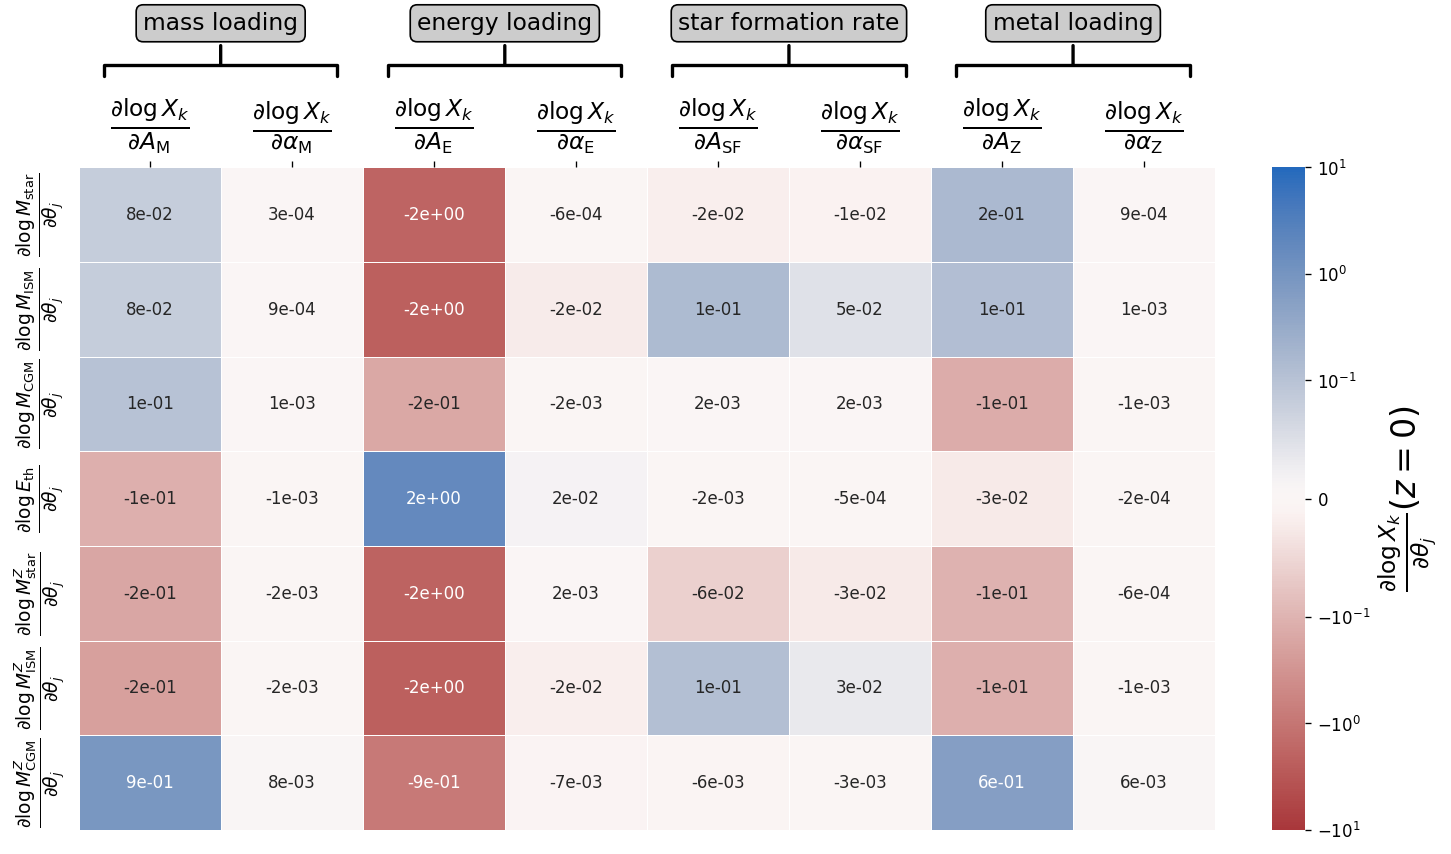

In [10]:



fig, ax = plt.subplots(figsize=(12,7),constrained_layout=True)

ylabels = [r'$\frac{\partial \log M_{\rm star}}{\partial \theta_j}$',
           r'$\frac{\partial \log M_{\rm ISM}}{\partial \theta_j}$',
           r'$\frac{\partial \log M_{\rm CGM}}{\partial \theta_j}$',
           r'$\frac{\partial \log E_{\rm th}}{\partial \theta_j}$',
           r'$\frac{\partial \log M_{\rm star}^{Z}}{\partial \theta_j}$',
           r'$\frac{\partial \log M_{\rm ISM}^{Z}}{\partial \theta_j}$',
           r'$\frac{\partial \log M_{\rm CGM}^{Z}}{\partial \theta_j}$',]

xlabels = [r'$\frac{\partial \log X_k}{\partial A_{\rm M}}$',
           r'$\frac{\partial \log X_k}{\partial \alpha_{\rm M}}$',
           r'$\frac{\partial \log X_k}{\partial A_{\rm E}}$',
           r'$\frac{\partial \log X_k}{\partial \alpha_{\rm E}}$',
           r'$\frac{\partial \log X_k}{\partial A_{\rm SF}}$',
           r'$\frac{\partial \log X_k}{\partial \alpha_{\rm SF}}$',
           r'$\frac{\partial \log X_k}{\partial A_{\rm Z}}$',
           r'$\frac{\partial \log X_k}{\partial \alpha_{\rm Z}}$',]

sns.heatmap(jac, annot=True, fmt=".0e", linewidths=.5,ax=ax,
            cmap=sns.color_palette("vlag_r", as_cmap=True),cbar_kws={'label':r'$\frac{\partial \log X_k}{\partial \theta_j}$'},
            yticklabels=ylabels,xticklabels=xlabels,norm=SymLogNorm(vmin=-10,vmax=10,linthresh=0.1))#vmin=-2,vmax=2,)

cbar = ax.collections[0].colorbar
cbar.set_label(r'$\frac{\partial \log X_k}{\partial \theta_j}(z=0)$',fontsize=20)

ax.tick_params(axis='both',which='both',left=False,right=False,top=False,bottom=False)
ax.set_xticklabels(xlabels,fontsize=20)
ax.set_yticklabels(ylabels,fontsize=16)

ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)

# add annotations with brackets above each "group" of (amplitude,slope) params
groups = [(0, 1), (2, 3), (4, 5), (6, 7)]
group_labels = ['mass loading', 'energy loading', 'star formation rate', 'metal loading']

# annotate each group with a bracket
for i, (start, end) in enumerate(groups):
    
    # place annotations above xticklabels using axes fraction coordinates
    xy = ((start+1.0) / len(xlabels), 1.15)
    xytext = (end / len(xlabels), 1.2)
    widthB = 5.0
    
    ax.annotate(group_labels[i], 
                xy=xy,  # position of group (in axes fraction)
                xytext=xytext,  # Ending position of the group (in axes fraction)
                fontsize=14, ha='center', va='bottom', 
                xycoords='axes fraction', 
                bbox=dict(boxstyle='round,pad=0.3', fc='0.8'),
                arrowprops=dict(arrowstyle='-[, widthB=%s, lengthB=.5, angleB=0'%widthB, lw=2.0))

# plt.savefig('/mnt/ceph/users/vpandya/sapphire_outputs/figures/figure_jacobian_singleMW_paper.png',
#             dpi=300,bbox_inches='tight',facecolor='w')



# Jacobians across parameter space

This requires multi-GPU parallelization

In [12]:
### now we'll change the runtype to 'sampling' for 1K latin hypercube samples
config['runtype'] = 'sampling'
config['sampling_config']['method'] = 'latin_hypercube' 
config['sampling_config']['Nsamples'] = 1000

# with 1K halos * 1K params = 10^6 ODEs to solve and autodiff through
# on 4 Nvidia A100-80GB GPUs this can take a couple min -- we can turn off the second post-jit run to save time
config['post_jit_benchmark'] = False

In [13]:
# run sapphire
out_sapphire2 = sapphire.run(config)
sol2, free_params_arr2, sol_jac2 = out_sapphire2

reading /mnt/ceph/users/vpandya/sapphire/scripts/config.yaml

your full sapphire config:

{   'Nbatch': 1000,
    'chain_num': 0,
    'clip_etaE_max': 1.0,
    'coolfunc': 'sd93',
    'data_path': '/mnt/ceph/users/vpandya/sapphire/data/',
    'flag_fgas': 1,
    'flag_mzr': 0,
    'flag_mzr_gas': 1,
    'flag_sfms': 0,
    'flag_smhm': 1,
    'inference_config': {   'Nadam': 3,
                            'adam_logL': 'manual',
                            'engine': 'adam',
                            'fit_mock': True,
                            'fit_obs': False,
                            'num_samples': 1000,
                            'num_warmup': 1000,
                            'random_mock': True,
                            'write_output': True},
    'mock_err_fgas': 0.0,
    'mock_err_mzr': 0.0,
    'mock_err_mzr_gas': 0.0,
    'mock_err_sfms': 0.0,
    'mock_err_smhm': 0.0,
    'model': 'pandya23',
    'num_cpus': 50,
    'obs_name': 'manga',
    'output_path': '/mnt/ceph/u

In [17]:
# now the batched jacobian is of shape = (N realizations, N halos, N state, N parameters) 
sol_jac2.shape

(1000, 1000, 7, 8)

In [45]:
from jax import config as jax_config
jax_config.update("jax_enable_x64", True) # required to accurately solve and take gradients through our diffeqs 

import jax
import jax.numpy as jnp
from jax import jit, vmap
from functools import partial
from jax.experimental import mesh_utils
from jax.experimental.shard_map import shard_map
from jax.sharding import Mesh, PartitionSpec, NamedSharding
from timeit import default_timer as timer
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [58]:
# final mvir is the same in every realization
final_mvirs = jnp.log10(sol2.ys[1]['Mvir'][0,:,0])
final_mvirs.shape, free_params_arr2.shape 

((1000,), (1000, 8))

In [39]:
Ndevices = jax.local_device_count()
mesh = Mesh(mesh_utils.create_device_mesh((Ndevices,)), axis_names=('i',))

In [42]:
### function that computes fractional sensitivity of every jacobian column

@jit
@partial(shard_map,mesh=mesh,in_specs=(PartitionSpec('i'),PartitionSpec(None)),out_specs=PartitionSpec('i'),check_rep=False)
@partial(vmap,in_axes=(0,None))
@partial(vmap,in_axes=(None,0))
def jacnorm(pindex,hindex):
    ### sol_jac2.shape = (Nparams, Nhalos, 7, 8)
    return (jnp.linalg.norm(sol_jac2[pindex,hindex],axis=0) / jnp.linalg.norm(sol_jac2[pindex,hindex]))     
    
tstart = timer()
jacnorm_coltot = jacnorm(jnp.arange(sol_jac2.shape[0]),jnp.arange(sol_jac2.shape[1]))
print(jacnorm_coltot[0])
print('took %.2f sec'%(timer()-tstart))    

[[8.55395993e-02 2.83800376e-02 8.72794048e-01 ... 3.26641668e-02
  2.60100925e-01 3.14201249e-04]
 [1.33985891e-01 8.69068960e-02 7.45918286e-01 ... 1.00220807e-01
  3.88938534e-01 2.03693163e-03]
 [5.72574147e-02 1.66507497e-02 9.19220620e-01 ... 4.65785615e-02
  1.84997369e-01 2.96761039e-04]
 ...
 [1.29684179e-01 4.05382745e-02 8.30414836e-01 ... 2.57558496e-02
  3.41348717e-01 7.79399644e-04]
 [9.91102075e-02 3.58541105e-01 0.00000000e+00 ... 5.19782879e-01
  6.73249648e-01 1.67986324e-02]
 [4.41946314e-02 2.56967094e-02 9.17940297e-01 ... 7.36805649e-02
  1.61105443e-01 5.88956075e-04]]
took 9.47 sec


In [43]:
jacnorm_coltot.shape

(1000, 1000, 8)

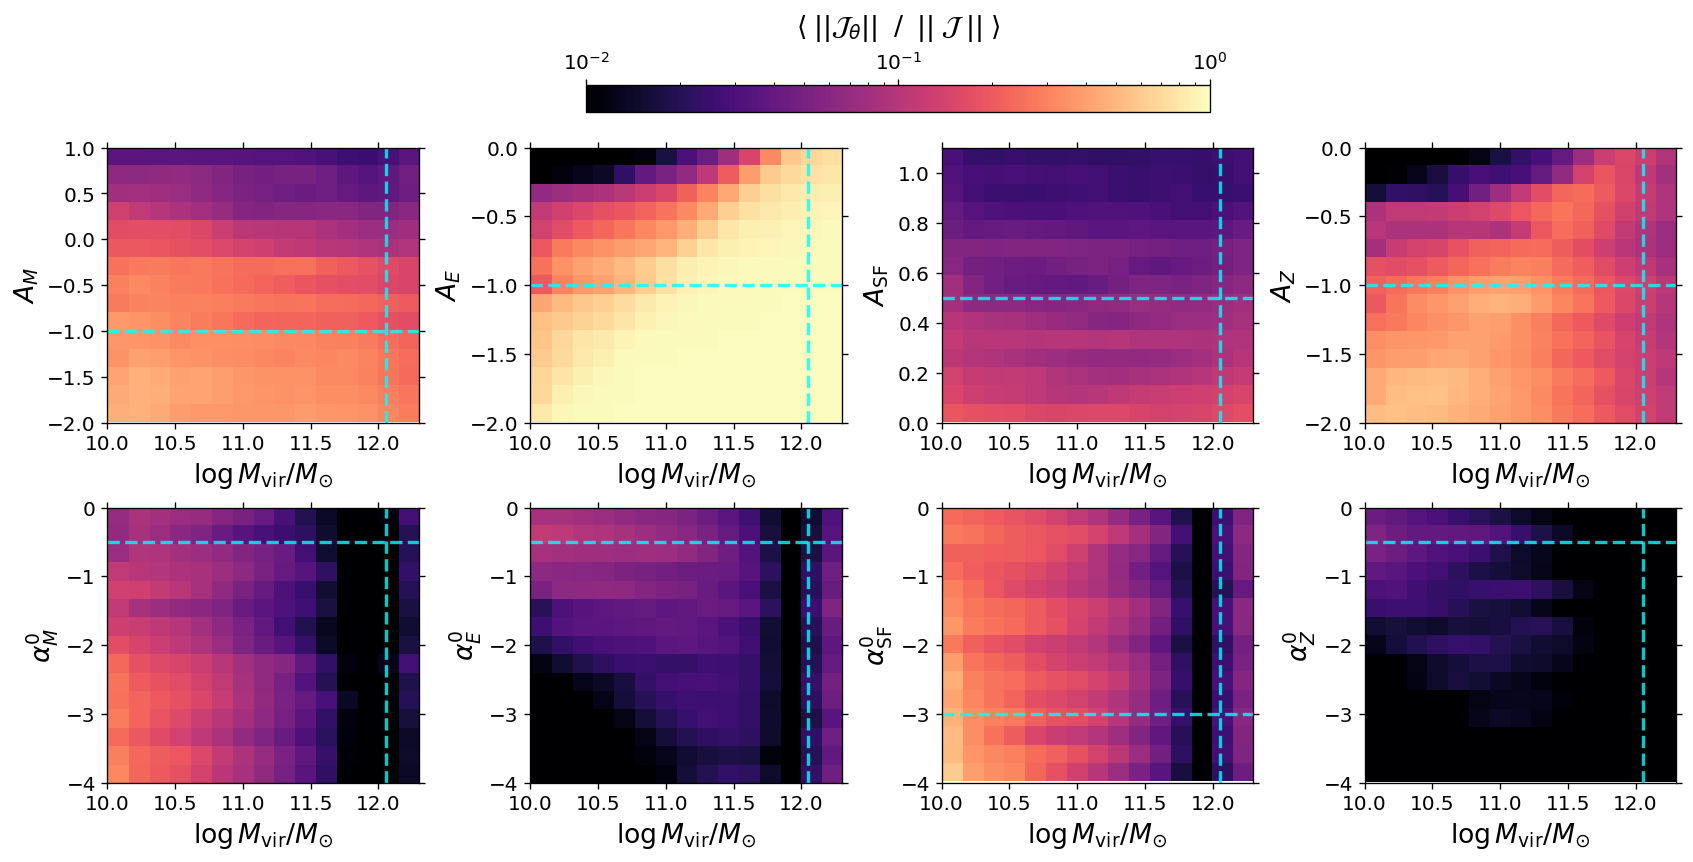

In [77]:
state_labels = [r'$M_{\rm star}$',r'$M_{\rm ISM}$',r'$M_{\rm CGM}$',r'$E_{\rm CGM}^{\rm th}$',
                r'$M_{\rm star}^Z$',r'$M_{\rm ISM}^Z$',r'$M_{\rm CGM}^Z$']

par_labels = {'A_M':r'$A_M$','alpha0_M':r'$\alpha_M^0$','A_E':r'$A_E$','alpha0_E':r'$\alpha_E^0$',
              'A_SF':r'$A_{\rm SF}$','alpha0_SF':r'$\alpha_{\rm SF}^0$',
              'A_Z':r'$A_Z$','alpha0_Z':r'$\alpha_Z^0$'}
param_names = list(par_labels.keys())

params_bounds = config['sampling_config']['params_bounds']


nbins_x, nbins_y = 15, 15
    
# set up figure
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(14, 6), constrained_layout=True)
allax = np.ravel(axes)

# put amplitudes on top row, slopes on bottom row
axmap = {'A_M':0,'A_E':1,'A_SF':2,'A_Z':3,
         'alpha0_M':4,'alpha0_E':5,'alpha0_SF':6,'alpha0_Z':7}

# loop over 8 parameters
for i in range(8):
    x = np.repeat(final_mvirs[None, :], free_params_arr2.shape[0], axis=0).flatten()  # shape (1K*1K,)
    y = np.repeat(free_params_arr2[:, i][:, None], len(final_mvirs), axis=1).flatten()
    z = jacnorm_coltot[:, :, i].flatten()

    # compute 2D histogram
    sum_vals, xedges, yedges = np.histogram2d(x, y, bins=[nbins_x, nbins_y], weights=z)
    counts, _, _ = np.histogram2d(x, y, bins=[xedges, yedges])
    mean_vals = sum_vals / np.maximum(counts, 1)
    mean_vals = mean_vals.T  # for imshow

    # plot 
    ax = allax[axmap[param_names[i]]]
    img = ax.imshow(mean_vals, origin='lower', aspect='auto',
                    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                    cmap='magma', norm=LogNorm(vmin=1e-2,vmax=1))#vmin=0, vmax=1)
    
    ax.set_xlabel(r'$\log M_{\rm vir}/M_{\odot}$', fontsize=16)
    ax.set_ylabel(par_labels[param_names[i]], fontsize=16)
    ax.tick_params(labelsize=12)

    ax.set_ylim(params_bounds[param_names[i]])
    ax.set_xticks(np.arange(10,12.5,0.5))

    ### mark axhline and mvir for example MW halo from previous section
    ax.axhline(free_params_arr[i],color='cyan',alpha=0.8,lw=2,ls='--')
    ax.axvline(sol_logmvir[ind_mw[0]][0],color='cyan',alpha=0.8,lw=2,ls='--')

# Shared colorbar
cax = inset_axes(allax[1], width="200%", height="10%", loc="upper center", borderpad=2,
                 bbox_transform=allax[1].transAxes, bbox_to_anchor=(0.68, 0.35, 1, 1))
cbar = fig.colorbar(img, cax=cax, orientation='horizontal')
# cbar.set_label(r'$\langle \frac{||\partial X_k / \partial \theta_j||}{||J||} \rangle$',fontsize=16)
cbar.set_label(r'$\langle\; ||\mathcal{J}_{\theta}|| \;\;/\;\; ||\;\mathcal{J}\;|| \;\rangle$',fontsize=16,labelpad=10)
cax.xaxis.set_label_position('top',)
cax.xaxis.set_ticks_position('top')
cax.tick_params(labelsize=12)


# plt.savefig('/mnt/ceph/users/vpandya/sapphire_outputs/figures/figure_jacobian_allcolnorms_final.png',
#             dpi=300,bbox_inches='tight',facecolor='w')
    


